# Number of Elements Sweep

This notebook analyzes how focusing efficiency scales with the number of diffractive elements in the cascade. It loads results from the `fig1_N_sweeps` study (multiple optimization runs for statistical robustness) and compares both the optimized cascade efficiency and the Fresnel zone plate baseline across different element counts and material choices.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

In [2]:
import sys

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

In [12]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

In [4]:
fzp_color = (np.float64(0.4), np.float64(0.6509803921568628), np.float64(0.11764705882352941), np.float64(1.0))

In [5]:
path = repo_root / "paper_data"

results = []
N_runs = 5
for i in range(N_runs):
    res = np.load(path / f"fig1_N_sweeps_results_run_{i}.npz", allow_pickle=True)
    results.append(res)
params = np.load(path / "fig1_N_sweeps_params.npy", allow_pickle=True).item()
sweep_arrs = np.load(path / "fig1_N_sweeps_sweep_arrays.npy", allow_pickle=True).item()

In [6]:
materials = sweep_arrs["materials"]
Nelems = sweep_arrs["Nelems"]

In [7]:
opt_efficiencies = np.zeros((N_runs, len(materials), Nelems.shape[0]))
fzp_efficiencies = np.zeros((N_runs, len(materials), Nelems.shape[0]))



for i in range(N_runs):
    opt_efficiencies_i = results[i]["opt_efficiencies"]
   
    fzp_efficiencies_i = results[i]["fzp_efficiencies"]

    opt_efficiencies[i] = opt_efficiencies_i
    fzp_efficiencies[i] = fzp_efficiencies_i

In [8]:
opt_efficiencies_mean = np.mean(opt_efficiencies, axis=0)
opt_efficiencies_std = np.std(opt_efficiencies, axis=0)

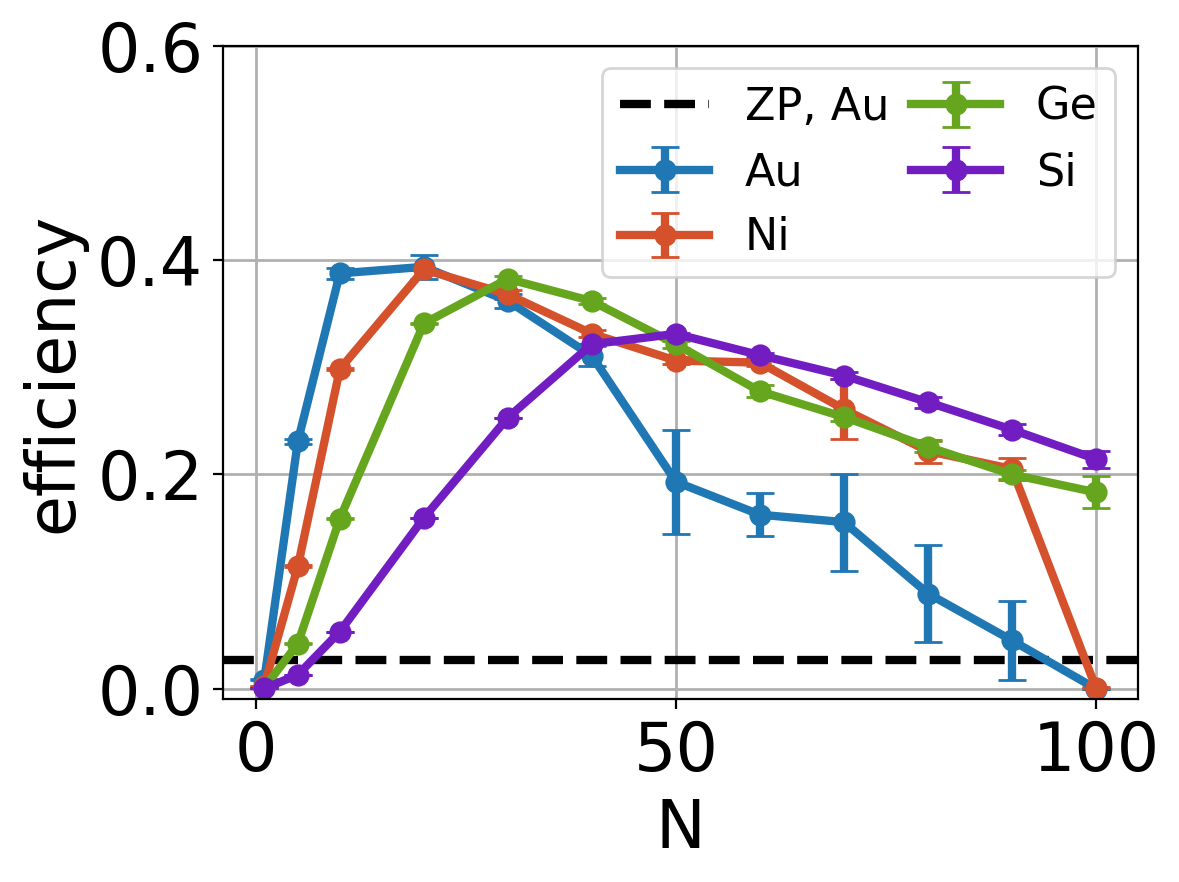

In [13]:

ni_color = (212/255, 81/255, 44/255)
ge_color = fzp_color
si_color = (114/255, 29/255, 194/255)

colors = ['tab:blue', ni_color, ge_color, si_color]

for i in range(len(materials)):
    plt.errorbar(Nelems, opt_efficiencies_mean[i, :], yerr=opt_efficiencies_std[i, :], label=materials[i].capitalize(), linewidth=3, fmt='-o', capsize=5, markersize=7, color=colors[i])

plt.axhline(fzp_efficiencies[0, 0, 0], linewidth=3, linestyle='--', color='black', label='ZP, Au')

plt.xlabel("N")
plt.ylabel("efficiency")
plt.legend(fontsize=16, ncol=2, labelspacing=0.5, columnspacing=0.5)
plt.tight_layout()
plt.grid(True, linewidth=1)
plt.ylim(-0.01, 0.6)
plt.show()